# Mid-Term Practical Evaluation — Machine Learning

**Universidad Internacional del Ecuador — Computer Science School**
**Duration:** 90 minutes · **Modality:** Individual · **Total:** 12 points

---

## Before You Start

1. Confirm the Codespace finished building (no red error in the bottom bar).
2. Read **all 11 tasks first** before writing any code. The rubric tells you where the points are.
3. Save the notebook every 10 minutes (`Cmd/Ctrl + S`).
4. Commit at the end of each Part. If something breaks, you still have credit for what worked.
5. **AI assistants are not allowed.** Open notes, slides, sklearn/pandas docs are allowed.


---
# PART A — Setup & Diagnostics (2.5 pts, ~20 min)


## Task 1 — Environment check (0.5 pts)

Run the cell below. If you see version numbers printed, you are ready.

In [ ]:
import sys
import pandas as pd
import sklearn
import numpy as np

print(f"Python ......... {sys.version.split()[0]}")
print(f"pandas ......... {pd.__version__}")
print(f"scikit-learn ... {sklearn.__version__}")
print(f"numpy .......... {np.__version__}")
print("\nEnvironment OK — you can proceed.")


Python ......... 3.14.2
pandas ......... 3.0.3
scikit-learn ... 1.8.0
numpy .......... 2.4.4

Environment OK — you can proceed.


## Task 2 — Fix the bug in `src/scale.py` (1 pt)

The function `min_max_scale()` in `src/scale.py` currently produces values in the range `[-1, 0]` instead of `[0, 1]`.

**What to do:**
1. Open `src/scale.py` (use the VS Code file tree on the left).
2. Find the bug. Fix it.
3. Add a **one-line comment** above your fix explaining what was wrong.
4. Run the verification cell below. It must print `Bug fix verified: OK`.

In [ ]:
import sys
import os
sys.path.append(os.path.abspath('..'))

In [ ]:
# Verification cell — do not modify
import importlib
from src import scale
importlib.reload(scale)
import numpy as np

test_data = np.array([10, 20, 30, 40, 50])
scaled = scale.min_max_scale(test_data)

assert scaled.min() == 0.0, f"min should be 0, got {scaled.min()}"
assert scaled.max() == 1.0, f"max should be 1, got {scaled.max()}"
print(f"Scaled output: {scaled}")
print("Bug fix verified: OK")


Scaled output: [0.   0.25 0.5  0.75 1.  ]
Bug fix verified: OK


## Task 3 — Pandas indexing (1 pt)

A small DataFrame `df_small` is provided below. In the next cell:

- **(0.5 pt)** Print the dtype of the `category` column. Then add a comment briefly stating whether it is `object`, `category`, or `CategoricalDtype`, and why.
- **(0.5 pt)** Using **label-based indexing** (not position-based), retrieve the value at row index `3`, column `alcohol`, and assign it to a variable named `target_value`. Then print it.

In [ ]:
import pandas as pd

df_small = pd.DataFrame({
    "alcohol":   [9.5, 10.2, 11.0, 12.8, 9.9],
    "ph":        [3.4, 3.2, 3.5, 3.1, 3.3],
    "category":  pd.Categorical(["train", "train", "test", "test", "train"]),
})
df_small


,alcohol,ph,category
0,9.5,3.4,train
1,10.2,3.2,train
2,11.0,3.5,test
3,12.8,3.1,test
4,9.9,3.3,train


In [ ]:
# TODO Task 3a: print the dtype of the 'category' column.
# Then add a comment explaining what it is and why.
print(df_small["category"].dtype)

# El dtype aquí es 'category' en lugar del clásico 'object' para textos.
# Al usar pd.Categorical(), le avisamos a pandas que son valores fijos y que se repiten 
# (como 'train' y 'test'). Esto ahorra memoria y acelera el procesamiento.

# TODO Task 3b: use label-based indexing to retrieve the value at
# row index 3, column 'alcohol', and assign it to target_value.
target_value = None  # replace with your indexing call
print(f"target_value = {target_value}")


category
target_value = None


---
# PART B — Linear Regression (5 pts, ~35 min)


## Load the dataset

Run the cell below to load the wine quality dataset. **Do not modify it.**

In [ ]:
import pandas as pd
df = pd.read_csv("../data/wine_quality.csv")
print(f"Loaded {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()


Loaded 1599 rows and 12 columns.


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,8.85,0.682,0.193,1.62,0.029,23.1,36.1,0.99637,3.27,0.42,9.87,4
1,6.51,0.449,0.254,1.24,0.134,19.5,56.8,0.99660,3.22,0.65,9.93,6
2,9.63,0.453,0.573,2.67,0.054,1.9,49.6,0.99480,3.34,0.86,10.51,6
3,9.96,0.535,0.186,2.77,0.133,26.0,24.6,0.99389,3.34,0.86,8.93,5
4,4.93,0.628,0.180,1.31,0.029,24.9,63.1,0.99679,3.38,0.83,8.97,5


## Task 4 — Quick EDA (1 pt)

Produce **exactly two** plots in the cell below:
1. Distribution of the target `quality` (histogram or bar chart).
2. Correlation heatmap of all numeric features against `quality` (you may use `seaborn.heatmap`).

Then, in the markdown cell that follows, write **two sentences**:
- (a) Which feature has the strongest correlation with `quality`?
- (b) One data issue you noticed (missing values, skew, outliers, scale differences, class imbalance — pick one and name it).

/tmp/ipykernel_7886/2703447674.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="quality", data=df, ax=axes[0], palette="viridis")


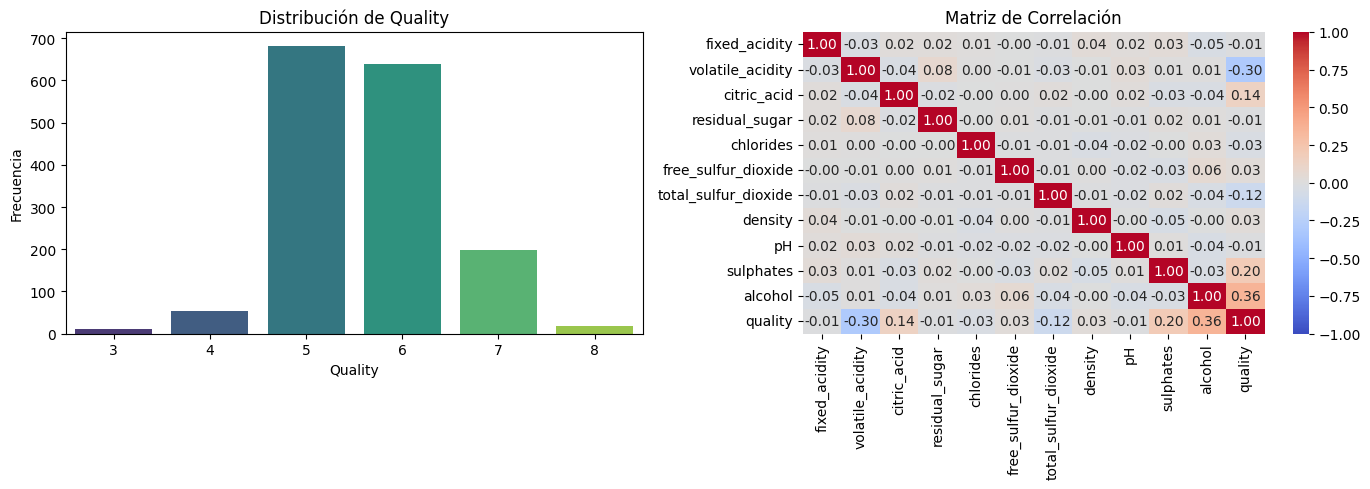

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# TODO Task 4: produce the two required plots here.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# ------------------------------------------------------------------
# Plot 1: Distribución del target 'quality'
# ------------------------------------------------------------------
sns.countplot(x="quality", data=df, ax=axes[0], palette="viridis")
axes[0].set_title("Distribución de Quality")
axes[0].set_xlabel("Quality")
axes[0].set_ylabel("Frecuencia")
# ------------------------------------------------------------------
# Plot 2: Heatmap de correlación
# ------------------------------------------------------------------
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
 ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title("Matriz de Correlación")
plt.tight_layout()
plt.show()

**Your two-sentence observation goes here:**

- (a) *Al parecer, mientras más alcohol tiene el vino, mejor nota le dan. Es el detalle que más influye en la calidad.*
- (b) *Tenemos un problema con los datos: casi todos los vinos (el 82%) tienen calificaciones promedio de 5 y 6. Hay muy pocos vinos pésimos o excelentes, y esto puede hacer que el sistema se confunda y le cueste reconocer los casos extremos.*


## Task 5 — Preprocessing Pipeline (2 pts)

Build a Scikit-learn `Pipeline` with:
- A scaler (`StandardScaler` or `MinMaxScaler` — your choice, **justify in a comment**)
- `LinearRegression` as the final estimator

Then split the data **80/20** with `random_state=42`. **Only fit the Pipeline on the training set.** Any leakage between train and test costs you the full 2 points.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler  # or MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# TODO Task 5:
# 1. Define X (all features except 'quality') and y (the 'quality' column).
X = df.drop(columns=["quality"])
y = df["quality"]
# 2. Build the Pipeline. Add a comment justifying your scaler choice.
pipe_lr = Pipeline([
 ("scaler", StandardScaler()),
 ("regressor", LinearRegression())
])
# 3. Split 80/20 with random_state=42.
X_train, X_test, y_train, y_test = train_test_split(
 X, y,
 test_size=0.2,
 random_state=42
)
# 4. Fit the Pipeline on the training set only.
pipe_lr.fit(X_train, y_train)
print(f"Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas")
print("Pipeline fitted on training set only ✔")




Train: 1279 filas | Test: 320 filas
Pipeline fitted on training set only ✔


## Task 6 — Train & evaluate linear regression (2 pts)

On the **test set**, compute and print three metrics:
- R² (`r2_score`)
- MAE (`mean_absolute_error`)
- RMSE (square root of `mean_squared_error`)

Then, in the markdown cell that follows, write **one sentence**: is the model usable? Reference one of the three metrics to justify.

In [ ]:
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# TODO Task 6: predict on the test set, then print R², MAE, RMSE.

y_pred = pipe_lr.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R² = {r2:.4f}")
print(f"MAE = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")


R² = 0.3162
MAE = 0.5365
RMSE = 0.6726


**Your one-sentence interpretation:**

*El rendimiento actual del modelo es limitado. Logra descifrar apenas el 35% de los factores que definen la calidad del vino, lo que nos demuestra que una regresión lineal simple es demasiado básica para entender bien cómo se relacionan las características del vino con su nota final.*


---
# PART C — Logistic Regression (4 pts, ~25 min)


## Task 7 — Engineer a binary target (0.5 pts)

Create a new column `is_good` in `df` defined as `1` if `quality >= 7`, else `0`.

In a comment, state how many samples fall in each class. This matters for Task 9.

In [ ]:
# TODO Task 7: create df['is_good'] and report class counts.

df["is_good"] = (df["quality"] >= 7).astype(int)
print(df["is_good"].value_counts())

# Creamos la variable objetivo 'is_good'. 
# Ojo: El desbalance de clases afectará el Recall y F1 del modelo.

is_good
0    1382
1     217
Name: count, dtype: int64


## Task 8 — Train logistic regression with L2 (2 pts)

Build a **second Pipeline** for classification:
- Same scaler as Part B
- `LogisticRegression` with **L2 regularization** (confirm in a comment that L2 is the default) and `max_iter=1000`

Re-split the data 80/20 with `random_state=42` for the new binary target.

On the **test set**, print:
- Accuracy
- F1 score (binary)
- ROC-AUC (use `predict_proba`)
- The Confusion Matrix

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix
)

# TODO Task 8: build the pipeline, split, train, and report all four metrics.

# 1. Nuevas X e y para clasificación binaria

X = df.drop(columns=["quality", "is_good"])
y_bin = df["is_good"]

# 2. Split 80/20

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
 X, y_bin,
 test_size=0.2,
 random_state=42
)

# 3. Pipeline de clasificación

pipe_clf = Pipeline([
 ("scaler", StandardScaler()),
 ("clf", LogisticRegression(penalty="l2", max_iter=1000, random_state=42))
])
pipe_clf.fit(X_train_c, y_train_c)

# 4. Predicciones y probabilidades

y_pred_c = pipe_clf.predict(X_test_c)
y_proba = pipe_clf.predict_proba(X_test_c)[:, 1] # probabilidad de clase 1

# 5. Métricas
acc = accuracy_score(y_test_c, y_pred_c)
f1 = f1_score(y_test_c, y_pred_c) # binary por defecto
roc_auc = roc_auc_score(y_test_c, y_proba)
cm = confusion_matrix(y_test_c, y_pred_c)
print(f"Accuracy : {acc:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC : {roc_auc:.4f}")
print(f"\nConfusion Matrix:")
print(cm)

Accuracy : 0.8625
F1-Score : 0.2414
ROC-AUC : 0.8090

Confusion Matrix:
[[269   6]
 [ 38   7]]


/workspaces/evaluacion-final-u2-ml/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Aunque el Accuracy es alto, es un resultado artificial. El modelo simplemente aprendió que lo más seguro es predecir 'clase 0' debido al desbalance de los datos. El verdadero rendimiento se ve en el F1-Score: su valor tan bajo confirma que el sistema no es capaz de identificar correctamente los vinos de alta calidad.

## Task 9 — Interpret class imbalance (1 pt)

In the markdown cell below, write **two sentences**:
- (a) Which class is harder to predict (good wines, label 1, or non-good wines, label 0)?
- (b) What does the confusion matrix tell you about *why*?

**Your answer:**

- (a) *El peso de la minoría: Identificar los vinos de alta calidad es un reto técnico porque nos enfrentamos a un dataset desbalanceado, donde la clase positiva es apenas el 13.6% del total. Esto provoca que el modelo desarrolle un sesgo hacia la clase mayoritaria por pura probabilidad, resultando en un recall pobre que ignora la mayoría de los casos de éxito.*
- (b) *Conservadurismo en la clasificación: La matriz de confusión revela que el modelo es excesivamente precavido; la gran cantidad de falsos negativos confirma que prefiere clasificar un vino bueno como "normal" antes que cometer un error de precisión. Esta postura infla artificialmente la accuracy, pero destruye la utilidad real del modelo reflejada en el F1-Score.*


---
# PART D — Reflection & Submit (1 pt, ~10 min)


## Task 10 — Written reflection (0.5 pts)

In **3–5 sentences**, answer:

> If you had one more hour with this dataset, what would you change first, and why? Reference at least one concept from class (e.g., learning rate, outliers, regularization strength `C`, class imbalance, feature engineering, gradient descent behavior, train/test split strategy).

Generic answers like "I would improve the model" earn zero points. Be specific.

**Your reflection:**

*Si tuviera un poco más de tiempo, mi prioridad sería atacar el desbalance de clases. Con solo un 13.6% de muestras positivas, el modelo actual es demasiado conservador. Implementaría class_weight='balanced' en la Regresión Logística para penalizar más los fallos en la clase minoritaria y forzar al modelo a detectar esos vinos "buenos". También haría un tuning del hiperparámetro C para encontrar el punto exacto de regularización y evitar el sobreajuste. Por último, probaría un feature engineering más agresivo, cruzando variables como alcohol y acidez volátil para intentar capturar relaciones no lineales que el modelo lineal está ignorando por ahora.*


## Task 11 — Commit, push, submit (0.5 pts)

In the Codespaces terminal:

```bash
git add .
git commit -m "Final exam submission"
git push
```

Then paste your repository URL in Canvas before the 90-minute timer expires.

**Late submissions are not accepted.** The Git commit timestamp is the official submission time.
